# CNN-GRU Blood Glucose Prediction from PPG Signals

This notebook implements the complete training pipeline for non-invasive glucose monitoring.

**Architecture**: CNN-GRU Hybrid  
**Target Performance**: MAE < 3.0 mg/dL, R² > 0.95  
**Dataset**: VitalDB or MUST

Based on: "Non-Invasive Glucose Level Monitoring from PPG using a Hybrid CNN-GRU Deep Learning Network" (2024)

## 0. Clone Repository

Clone the dl-model branch from GitHub to get all the source code.

In [1]:
# Clone the repository (dl-model branch)
!cd /kaggle/working && rm -rf 3x1-PPG
!git clone -b dl-model --single-branch https://github.com/omar-A-hassan/3x1-PPG.git
!ls -la /kaggle/working/3x1-PPG/src/

print("Repository cloned successfully")

Cloning into '3x1-PPG'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 84 (delta 32), reused 66 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 41.12 KiB | 1.11 MiB/s, done.
Resolving deltas: 100% (32/32), done.
total 32
drwxr-xr-x 7 root root 4096 Oct  7 17:16 .
drwxr-xr-x 5 root root 4096 Oct  7 17:16 ..
drwxr-xr-x 2 root root 4096 Oct  7 17:16 evaluation
-rw-r--r-- 1 root root  239 Oct  7 17:16 __init__.py
drwxr-xr-x 3 root root 4096 Oct  7 17:16 models
drwxr-xr-x 3 root root 4096 Oct  7 17:16 preprocessing
drwxr-xr-x 2 root root 4096 Oct  7 17:16 __pycache__
drwxr-xr-x 2 root root 4096 Oct  7 17:16 training
Repository cloned successfully


# Install dependencies


In [2]:
!pip install neurokit2 vitaldb xlstm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [3]:
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Add repo root to path for Kaggle
sys.path.insert(0, '/kaggle/working/3x1-PPG')

# Import from src modules
from src.models import build_cnn_gru
from src.preprocessing import PPGPreprocessor
from src.training import train_model
from src.evaluation import compute_all_metrics, print_metrics, clarke_error_grid_analysis

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB


## 2. Load VitalDB Dataset

**VitalDB** is an open dataset with 6,388 surgical patients containing:
- **PPG waveforms**: `SNUADC/PLETH` at 500 Hz
- **Glucose measurements**: Laboratory results (preoperative and perioperative)

We'll use the VitalDB Python API to access the data without manual downloads.

### VitalDB Track Information:
- **SNUADC/PLETH**: Plethysmography waveform (500 Hz)
- **Clinical data**: Includes `preop_gluc` (preoperative glucose in mg/dL)
- **Lab results**: Time-series glucose measurements during surgery

In [4]:
# Load VitalDB dataset using Python API with proper temporal alignment
import vitaldb
from tqdm import tqdm

print("Loading VitalDB dataset with temporal alignment...")
print("Following paper's method: 16-minute PPG windows centered on glucose measurements\n")

# Step 1: Load laboratory glucose data
print("Step 1: Loading laboratory glucose measurements...")
df_labs = pd.read_csv('https://api.vitaldb.net/labs')
glucose_labs = df_labs[df_labs['name'] == 'gluc'].copy()
print(f"Found {len(glucose_labs)} glucose measurements across {glucose_labs['caseid'].nunique()} cases")

# Step 2: Find cases with both PPG and glucose
print("\nStep 2: Finding cases with PPG signals...")
ppg_cases = set(vitaldb.find_cases(['SNUADC/PLETH']))
glucose_cases = set(glucose_labs['caseid'].unique())
common_cases = list(ppg_cases & glucose_cases)
print(f"Found {len(common_cases)} cases with both PPG and glucose data")

# Limit to subset for faster training
MAX_CASES = 2000  # Increase for full dataset
if len(common_cases) > MAX_CASES:
    common_cases = np.random.choice(common_cases, MAX_CASES, replace=False).tolist()
    print(f"Using subset of {MAX_CASES} cases for training")

# Step 3: Load PPG signals aligned with glucose measurements
print(f"\nStep 3: Loading time-aligned PPG-glucose pairs from {len(common_cases)} cases...")
print("Extracting 16-minute windows (±8 min around glucose measurement)")

ppg_signals = []
glucose_values = []
patient_ids = []
sampling_rate = 100  # Downsample to 100Hz

# Paper's window: 8 minutes before + 8 minutes after = 16 minutes
WINDOW_MINUTES = 16
WINDOW_SECONDS = WINDOW_MINUTES * 60
WINDOW_SAMPLES = WINDOW_SECONDS * sampling_rate  # 96,000 samples at 100Hz

skipped_cases = 0
total_windows = 0

for caseid in tqdm(common_cases, desc="Loading cases"):
    try:
        # Load PPG signal at 100Hz (downsample from 500Hz)
        vals = vitaldb.load_case(caseid, ['SNUADC/PLETH'], 1/sampling_rate)
        
        if vals is None or len(vals) == 0:
            skipped_cases += 1
            continue
        
        ppg_track = vals[:, 0]
        
        # Get all glucose measurements for this case
        case_glucose = glucose_labs[glucose_labs['caseid'] == caseid]
        
        if len(case_glucose) == 0:
            skipped_cases += 1
            continue
        
        # For each glucose measurement, extract 16-minute PPG window
        for _, glucose_row in case_glucose.iterrows():
            glucose_time = glucose_row['dt']  # Time in seconds
            glucose_value = glucose_row['result']
            
            # Skip invalid glucose values
            if glucose_value < 40 or glucose_value > 600:  # Physiologically impossible
                continue
            
            # Convert glucose time to sample index at 100Hz
            # dt is in seconds, so glucose_idx = glucose_time * sampling_rate
            glucose_idx = int(glucose_time * sampling_rate)
            
            # Calculate 16-minute window: ±8 minutes from glucose measurement
            half_window = WINDOW_SAMPLES // 2  # 48000 samples
            window_start = glucose_idx - half_window
            window_end = glucose_idx + half_window
            
            # Check if we have enough PPG data for full 16-minute window
            if window_start < 0 or window_end > len(ppg_track):
                continue
            
            # Extract PPG window
            ppg_window = ppg_track[window_start:window_end]
            
            # Skip if window has too many NaN values
            if np.isnan(ppg_window).sum() / len(ppg_window) > 0.5:
                continue
            
            ppg_signals.append(ppg_window)
            glucose_values.append(glucose_value)
            patient_ids.append(caseid)
            total_windows += 1
        
    except Exception as e:
        skipped_cases += 1
        continue

ppg_signals = np.array(ppg_signals)
glucose_values = np.array(glucose_values)
patient_ids = np.array(patient_ids)

print(f"\n{'='*60}")
print(f"VitalDB Dataset Loaded Successfully")
print(f"{'='*60}")
print(f"Total samples: {len(ppg_signals)}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
if len(ppg_signals) > 0:
    print(f"PPG window shape: {ppg_signals[0].shape} (16 minutes at {sampling_rate}Hz)")
    print(f"Glucose range: {glucose_values.min():.1f} - {glucose_values.max():.1f} mg/dL")
    print(f"Glucose mean ± std: {glucose_values.mean():.1f} ± {glucose_values.std():.1f} mg/dL")
print(f"Skipped cases: {skipped_cases}")
print(f"{'='*60}")


Loading VitalDB dataset with temporal alignment...
Following paper's method: 16-minute PPG windows centered on glucose measurements

Step 1: Loading laboratory glucose measurements...
Found 35358 glucose measurements across 5091 cases

Step 2: Finding cases with PPG signals...
Found 4872 cases with both PPG and glucose data
Using subset of 2000 cases for training

Step 3: Loading time-aligned PPG-glucose pairs from 2000 cases...
Extracting 16-minute windows (±8 min around glucose measurement)


Loading cases: 100%|██████████| 2000/2000 [35:30<00:00,  1.07s/it]



VitalDB Dataset Loaded Successfully
Total samples: 2996
Unique patients: 1282
PPG window shape: (96000,) (16 minutes at 100Hz)
Glucose range: 43.0 - 483.0 mg/dL
Glucose mean ± std: 119.8 ± 36.7 mg/dL
Skipped cases: 0


## 3. Preprocess PPG Signals

In [5]:
# Initialize preprocessor with paper's exact parameters
preprocessor = PPGPreprocessor(
    sampling_rate=sampling_rate,
    segment_length=1.0,  # Extract 1-second segments from 16-minute windows
    lowcut=0.5,
    highcut=8.0,
    peak_height_threshold=20,       # Paper's threshold
    peak_distance_factor=0.8,       # 80 samples at 100Hz
    similarity_threshold=0.85       # Paper's 85%
)

print("Preprocessing PPG signals...")
print("Extracting 1-second peak-centered windows from 16-minute PPG signals")
print("IMPORTANT: Subsampling to ~200 segments per measurement to match paper's duplication ratio\n")

# Preprocess all signals
processed_segments = []
processed_glucose = []
processed_patient_ids = []

# Paper's duplication analysis:
# - They had 699,072 10-second segments from 35,358 glucose measurements = 19.8 segments/measurement
# - Then extracted 1-second peaks from each 10-second segment (~10 peaks per 10-sec)
# - Estimated final: ~200 1-second segments per glucose measurement
MAX_SEGMENTS_PER_MEASUREMENT = 200

for ppg_window, glucose, patient_id in tqdm(zip(ppg_signals, glucose_values, patient_ids), total=len(ppg_signals), desc="Processing signals"):
    # Preprocess 16-minute window using paper's Algorithm 1
    # This extracts multiple 1-second segments centered on detected peaks
    segments = preprocessor.preprocess(ppg_window, apply_template_matching=True)
    
    if segments is None or len(segments) == 0:
        continue
    
    # CRITICAL FIX: Subsample to match paper's duplication ratio
    # Paper: ~200 segments per measurement (from 10-sec chunking approach)
    # Our current: ~410 segments per measurement (extracting all peaks from 16-min window)
    if len(segments) > MAX_SEGMENTS_PER_MEASUREMENT:
        # Randomly sample to reduce duplication and prevent overfitting
        indices = np.random.choice(len(segments), MAX_SEGMENTS_PER_MEASUREMENT, replace=False)
        segments = [segments[i] for i in sorted(indices)]
    
    # Each 1-second segment from this 16-minute window gets the same glucose value
    for segment in segments:
        processed_segments.append(segment)
        processed_glucose.append(glucose)
        processed_patient_ids.append(patient_id)

X = np.array(processed_segments, dtype=np.float32)  # (n_samples, 100)
y = np.array(processed_glucose, dtype=np.float32)
patient_ids_processed = np.array(processed_patient_ids)

print(f"\nPreprocessed data:")
print(f"  Total 1-second segments: {len(X)}")
print(f"  Segment shape: {X[0].shape} (1 second at 100Hz)")
print(f"  Average segments per 16-min window: {len(X) / len(ppg_signals):.1f}")
print(f"  Unique patients: {len(np.unique(patient_ids_processed))}")
print(f"\n  Duplication reduction: {MAX_SEGMENTS_PER_MEASUREMENT} segments max per glucose measurement")


Preprocessing PPG signals...
Extracting 1-second peak-centered windows from 16-minute PPG signals
IMPORTANT: Subsampling to ~200 segments per measurement to match paper's duplication ratio



Processing signals: 100%|██████████| 2996/2996 [00:34<00:00, 86.63it/s]



Preprocessed data:
  Total 1-second segments: 377421
  Segment shape: (100,) (1 second at 100Hz)
  Average segments per 16-min window: 126.0
  Unique patients: 1214

  Duplication reduction: 200 segments max per glucose measurement


## 4. Train/Test Split by Patient

In [6]:
from sklearn.model_selection import train_test_split

# Split by patient ID to prevent data leakage
unique_patients = np.unique(patient_ids_processed)
print(f"Total unique patients: {len(unique_patients)}")

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

# Further split train into train/val
train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.2,
    random_state=42
)

# Create masks
train_mask = np.isin(patient_ids_processed, train_patients)
val_mask = np.isin(patient_ids_processed, val_patients)
test_mask = np.isin(patient_ids_processed, test_patients)

# Split data
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"\nData split:")
print(f"  Train: {len(X_train)} samples from {len(train_patients)} patients")
print(f"  Val: {len(X_val)} samples from {len(val_patients)} patients")
print(f"  Test: {len(X_test)} samples from {len(test_patients)} patients")

# Verify no patient overlap
assert len(set(train_patients) & set(val_patients)) == 0
assert len(set(train_patients) & set(test_patients)) == 0
assert len(set(val_patients) & set(test_patients)) == 0
print("\nData split verification: No patient overlap")

Total unique patients: 1214

Data split:
  Train: 235760 samples from 776 patients
  Val: 62773 samples from 195 patients
  Test: 78888 samples from 243 patients

Data split verification: No patient overlap


## 5. Build Model

In [7]:
from src.models import XLSTM_AVAILABLE

if XLSTM_AVAILABLE:
    from src.models import build_xlstm_ppg

    print("Building xLSTM model...")
    model_xlstm = build_xlstm_ppg(
        input_length=100,
        embedding_dim=64,      # Tiny model
        num_blocks=4,
        dropout=0.3,
        slstm_at=[1]
    )

    print(f"xLSTM Parameters: {model_xlstm.count_parameters():,}")

Building xLSTM model...
xLSTM Parameters: 126,425


## 6. Train Model

In [8]:
# Training configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 32
epochs = 100
learning_rate = 0.001

# Train model
trainer = train_model(
    model_xlstm,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=learning_rate,
    device=device,
    save_dir='checkpoints'
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training CNN-GRU Model
Training samples: 235760
Validation samples: 62773
Batch size: 32
Device: cuda
Epoch 1/100
  Train Loss: 1793.2711, Train MAE: 30.93 mg/dL
  Val Loss: 1504.3131, Val MAE: 26.41 mg/dL
  LR: 0.001000
  → Best model saved (Val MAE: 26.41 mg/dL)
Epoch 2/100
  Train Loss: 1511.0115, Train MAE: 28.54 mg/dL
  Val Loss: 1500.3225, Val MAE: 27.34 mg/dL
  LR: 0.001000
  → Best model saved (Val MAE: 27.34 mg/dL)
Epoch 3/100
  Train Loss: 1459.1682, Train MAE: 27.98 mg/dL
  Val Loss: 1468.8272, Val MAE: 25.74 mg/dL
  LR: 0.001000
  → Best model saved (Val MAE: 25.74 mg/dL)
Epoch 4/100
  Train Loss: 1410.5504, Train MAE: 27.43 mg/dL
  Val Loss: 1552.3226, Val MAE: 26.33 mg/dL
  LR: 0.001000
Epoch 5/100
  Train Loss: 1407.6731, Train MAE: 27.40 mg/dL
  Val Loss: 1504.9718, Val MAE: 26.72 mg/dL
  LR: 0.001000
Epoch 6/100
  Train Loss: 1401.3697, Train MAE: 27.32 mg/dL
  Val Loss: 1498.5796, Val MAE: 26.32 mg/dL
  LR: 0.001000
Epoch 7/100
  Train Loss: 1392.2462, Train MAE: 27.2

## 7. Plot Training History

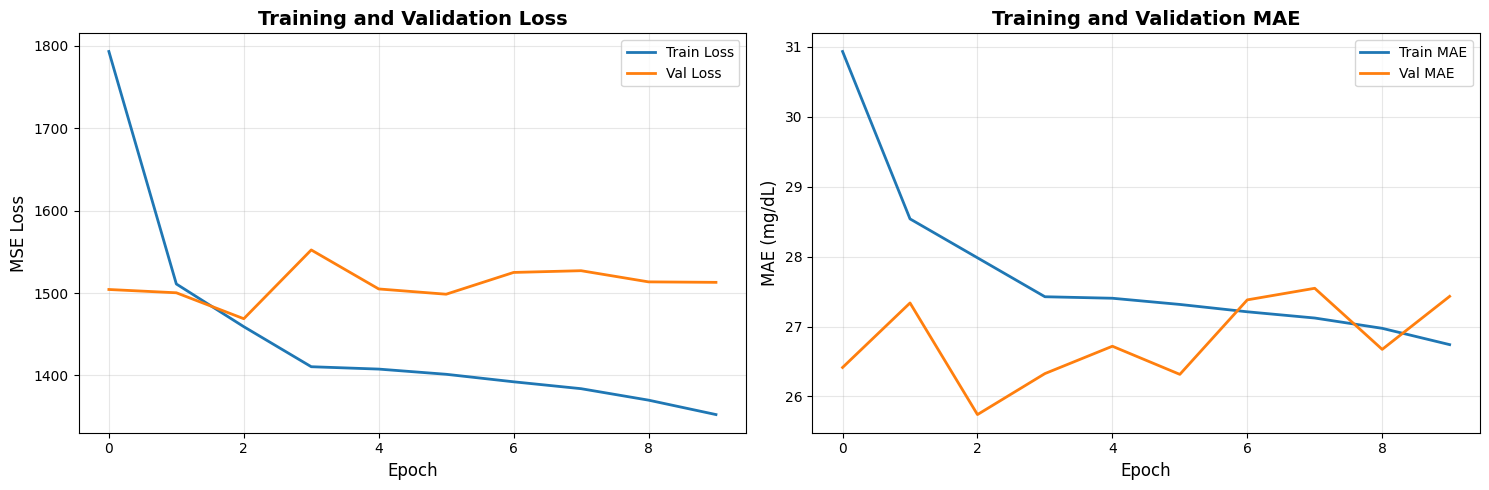


Best validation MAE: 25.74 mg/dL at epoch 11


In [9]:
history = trainer.history

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history['train_mae'], label='Train MAE', linewidth=2)
axes[1].plot(history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE (mg/dL)', fontsize=12)
axes[1].set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest validation MAE: {min(history['val_mae']):.2f} mg/dL at epoch {np.argmin(history['val_mae'])+1}")

## 8. Evaluate on Test Set

In [10]:
# Load best model
trainer.load_checkpoint('checkpoints/best_model.pt')

# Make predictions
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_pred = model(X_test_tensor).cpu().numpy().squeeze()

# Compute metrics
metrics = compute_all_metrics(y_test, y_pred)
print_metrics(metrics)

Loaded checkpoint from epoch 3
Val MAE: 25.74 mg/dL


NameError: name 'model' is not defined

## 9. Clarke Error Grid Analysis

In [ ]:
# Generate Clarke Error Grid
clarke_error_grid_analysis(
    y_test,
    y_pred,
    show_plot=True,
    save_path='clarke_error_grid.png'
)

## 10. Prediction Visualization

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, s=30, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('True Glucose (mg/dL)', fontsize=12)
plt.ylabel('Predicted Glucose (mg/dL)', fontsize=12)
plt.title('Predicted vs True Glucose Levels', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_pred - y_test
plt.scatter(y_test, residuals, alpha=0.5, s=30, edgecolors='k', linewidths=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('True Glucose (mg/dL)', fontsize=12)
plt.ylabel('Residual (mg/dL)', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Save Model for Deployment

In [ ]:
# Save model for inference
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_length': 100,
        'dropout': 0.3
    },
    'preprocessor_config': {
        'sampling_rate': sampling_rate,
        'segment_length': 1.0,
        'lowcut': 0.5,
        'highcut': 8.0
    },
    'test_metrics': metrics
}, 'cnn_gru_glucose_model.pth')

print("Model saved to: cnn_gru_glucose_model.pth")
